# 提取数据

In [230]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 读取数据
file_path = r"E:\\Grad\\data\\关键中转数据\\df_final.pkl"
if os.path.exists(file_path):
    df_final  = pd.read_pickle(file_path)
    print(f"✅ 成功加载数据，共 {len(df_final )} 条原始样本")
else:
    print("❌ 未找到数据文件，请检查路径！")

✅ 成功加载数据，共 1319 条原始样本


# 剔除高相关特征

📊 开始执行特征相关性分析与归一化 (完整修复版)...

✅ 初始数值特征数量: 16

🔄 正在计算皮尔逊相关系数矩阵...

🔍 正在筛选相关性 > 0.85 的特征对...
   ⚠️ 高相关检测: 'rpm_peak' 与 'rpm_mean' (r=0.9749) -> 剔除 'rpm_peak'
   ⚠️ 高相关检测: 'crest_factor_acc_fft' 与 'spectral_kurtosis_acc_fft' (r=0.9314) -> 剔除 'crest_factor_acc_fft'
   ⚠️ 高相关检测: 'spectral_entropy_acc_fft' 与 'spectral_kurtosis_acc_fft' (r=0.8799) -> 剔除 'spectral_entropy_acc_fft'
   ⚠️ 高相关检测: 'env_kurtosis' 与 'max_kurtosis' (r=0.8852) -> 剔除 'env_kurtosis'
   ⚠️ 高相关检测: 'env_crest_factor' 与 'env_kurtosis' (r=0.8551) -> 剔除 'env_crest_factor'

✅ 筛选结果汇总:
   - 原始数值特征数: 16
   - 剔除高相关特征数: 5
   - 最终保留特征数: 11

💾 已生成降维后的 DataFrame: df_reduced
   形状: (1319, 16)


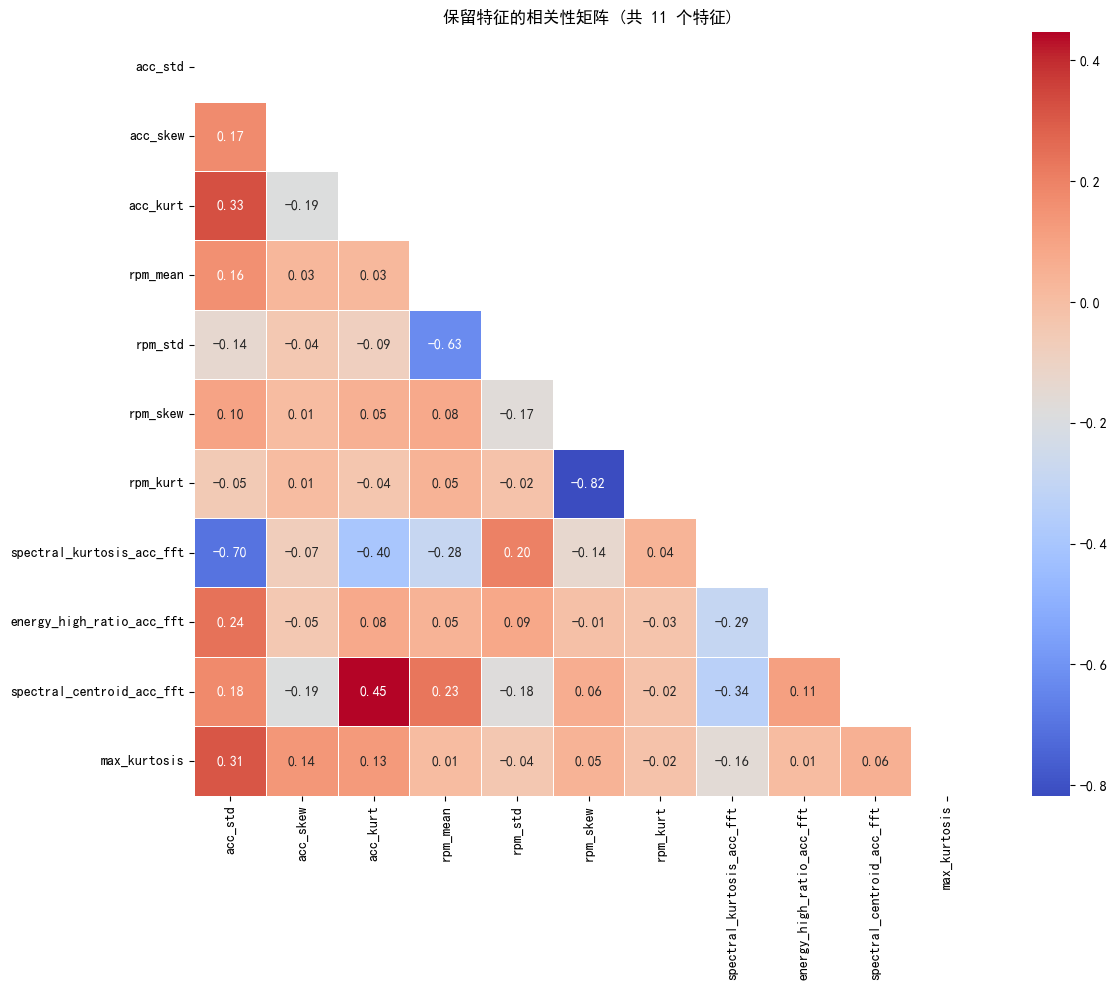


⚖️ 正在执行 Min-Max 归一化 [0, 1]...
   ✅ 已完成全量数据 Min-Max 归一化。
   - 归一化后最小值: 0.0000
   - 归一化后最大值: 1.0000

✅ 全部完成！
   - 最终 DataFrame: df_reduced
   - 最终特征列列表: feature_cols (已更新)
   - 特征数量: 11

📋 数据预览 (前 5 行):


,timestamp,turbine_id,data_category,sensor_loc_std,acceleration,acc_std,acc_skew,acc_kurt,rpm_mean,rpm_std,rpm_skew,rpm_kurt,spectral_kurtosis_acc_fft,energy_high_ratio_acc_fft,spectral_centroid_acc_fft,max_kurtosis
0,2023-10-17 08:32:21,04,Normal,NDE_径向,-0.8442383\n0.7069092\n0.8236084\n0.9979248\n0...,0.078242,0.580934,0.021588,0.609033,0.358925,0.861812,0.004280,0.870308,0.994937,0.464554,0.001096
1,2023-10-17 08:32:21,04,Normal,DE_轴向,0.9194336\n1.142822\n0.9880371\n0.4608154\n-0....,0.060255,0.567009,0.056477,0.609033,0.358925,0.861812,0.004280,0.627955,0.995435,0.417795,0.001678
2,2023-10-17 08:32:21,04,Normal,DE_径向,-3.299194\n-2.734741\n1.837646\n2.126831\n1.42...,0.055186,0.465216,0.051219,0.609033,0.358925,0.861812,0.004280,0.756159,0.991805,0.589173,0.011981
3,2023-10-17 16:32:24,04,Normal,DE_轴向,-1.274902\n-0.9530029\n-0.5905762\n0.000732421...,0.055737,0.565226,0.051174,0.434826,0.499211,0.915877,0.004373,0.759574,0.997269,0.427101,0.000754
4,2023-10-17 16:32:24,04,Normal,DE_径向,-2.385132\n-1.286133\n0.05334473\n1.00061\n1.7...,0.058161,0.477473,0.047634,0.434826,0.499211,0.915877,0.004373,0.757461,0.994475,0.573813,0.001514


In [231]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib  # 用于保存 scaler 模型

# --- 设置 Matplotlib 支持中文 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("📊 开始执行特征相关性分析与归一化 (完整修复版)...")

# ==========================================
# 1. 准备数据与智能过滤
# ==========================================
# 定义必须排除的列 (ID, 标签, 信号等)
exclude_names = [
    'timestamp', 'turbine_id', 'data_category', 'sensor_loc_std',
    'acceleration', 'label', 'fault_type' # 建议把标签列也排除在特征分析外
]

# 步骤 A: 先通过列名排除
candidate_cols = [col for col in df_final.columns if col not in exclude_names]

# 步骤 B: 【关键修复】进一步只保留数值型列
feature_cols = []
for col in candidate_cols:
    if pd.api.types.is_numeric_dtype(df_final[col]):
        feature_cols.append(col)
    else:
        print(f"   ⚠️ 自动跳过非数值列: '{col}' (类型: {df_final[col].dtype})")

print(f"\n✅ 初始数值特征数量: {len(feature_cols)}")
if len(feature_cols) == 0:
    raise ValueError("❌ 错误：没有找到任何数值型特征列！")

# 提取特征矩阵
X_features = df_final[feature_cols]

# ==========================================
# 2. 计算相关系数矩阵
# ==========================================
print("\n🔄 正在计算皮尔逊相关系数矩阵...")
corr_matrix = X_features.corr(method='pearson')

# ==========================================
# 3. 识别并剔除高相关特征
# ==========================================
threshold = 0.85  # 阈值
print(f"\n🔍 正在筛选相关性 > {threshold} 的特征对...")

to_drop = set()

# 遍历上三角矩阵
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = abs(corr_matrix.iloc[i, j])
        
        if corr_value > threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            
            # 策略：保留方差更大的那个，或者简单地保留前者剔除后者
            # 这里简单处理：剔除后者 (col_i)，保留前者 (col_j)
            to_drop.add(col_i)
            print(f"   ⚠️ 高相关检测: '{col_i}' 与 '{col_j}' (r={corr_value:.4f}) -> 剔除 '{col_i}'")

# 生成保留列表
cols_to_keep = [col for col in feature_cols if col not in to_drop]

print(f"\n✅ 筛选结果汇总:")
print(f"   - 原始数值特征数: {len(feature_cols)}")
print(f"   - 剔除高相关特征数: {len(to_drop)}")
print(f"   - 最终保留特征数: {len(cols_to_keep)}")

# ==========================================
# 4. 更新 DataFrame (构建 df_reduced)
# ==========================================
# 定义必须保留的元数据列
meta_cols = [
    'timestamp', 'turbine_id', 'data_category', 'sensor_loc_std',
    'acceleration', 'label', 'fault_type' # 确保标签列被保留
]
valid_meta_cols = [c for c in meta_cols if c in df_final.columns]

# 构建新的 DataFrame (先复制，避免 SettingWithCopyWarning)
df_reduced = df_final[valid_meta_cols + cols_to_keep].copy()

print(f"\n💾 已生成降维后的 DataFrame: df_reduced")
print(f"   形状: {df_reduced.shape}")

# ==========================================
# 5. 可视化 (仅当特征较少时)
# ==========================================
if len(cols_to_keep) <= 30:
    plt.figure(figsize=(12, 10))
    final_corr = df_reduced[cols_to_keep].corr()
    
    mask = np.triu(np.ones_like(final_corr, dtype=bool))
    sns.heatmap(final_corr, mask=mask, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
    plt.title(f'保留特征的相关性矩阵 (共 {len(cols_to_keep)} 个特征)')
    plt.tight_layout()
    plt.show()
else:
    print(f"\n📉 跳过热力图 (特征数 {len(cols_to_keep)} > 30)。")

# ==========================================
# 6. 【新增】Min-Max 归一化
# ==========================================
print("\n⚖️ 正在执行 Min-Max 归一化 [0, 1]...")

# 初始化缩放器
scaler = MinMaxScaler(feature_range=(0, 1))



scaler.fit(df_reduced[cols_to_keep])
df_reduced[cols_to_keep] = scaler.transform(df_reduced[cols_to_keep])

print("   ✅ 已完成全量数据 Min-Max 归一化。")
print(f"   - 归一化后最小值: {df_reduced[cols_to_keep].min().min():.4f}")
print(f"   - 归一化后最大值: {df_reduced[cols_to_keep].max().max():.4f}")

# ==========================================
# 7. 保存 Scaler (重要！)
# ==========================================
# 为了将来对新的实时数据进行同样的归一化，必须保存这个 scaler
# scaler_filename = "feature_minmax_scaler.pkl"
# joblib.dump(scaler, scaler_filename)
# print(f"\n💾 Scaler 已保存至 '{scaler_filename}'，请在推理阶段加载使用。")

# ==========================================
# 8. 最终检查
# ==========================================
print("\n✅ 全部完成！")
print(f"   - 最终 DataFrame: df_reduced")
print(f"   - 最终特征列列表: feature_cols (已更新)")
print(f"   - 特征数量: {len(cols_to_keep)}")

# 更新全局变量供后续 3 通道构建使用
feature_cols = cols_to_keep

# 显示前几行确认
print("\n📋 数据预览 (前 5 行):")
display(df_reduced[valid_meta_cols + cols_to_keep].head())

In [232]:
df_reduced

,timestamp,turbine_id,data_category,sensor_loc_std,acceleration,acc_std,acc_skew,acc_kurt,rpm_mean,rpm_std,rpm_skew,rpm_kurt,spectral_kurtosis_acc_fft,energy_high_ratio_acc_fft,spectral_centroid_acc_fft,max_kurtosis
0,2023-10-17 08:32:21,04,Normal,NDE_径向,-0.8442383\n0.7069092\n0.8236084\n0.9979248\n0...,0.078242,0.580934,0.021588,0.609033,0.358925,0.861812,0.004280,0.870308,0.994937,0.464554,0.001096
1,2023-10-17 08:32:21,04,Normal,DE_轴向,0.9194336\n1.142822\n0.9880371\n0.4608154\n-0....,0.060255,0.567009,0.056477,0.609033,0.358925,0.861812,0.004280,0.627955,0.995435,0.417795,0.001678
2,2023-10-17 08:32:21,04,Normal,DE_径向,-3.299194\n-2.734741\n1.837646\n2.126831\n1.42...,0.055186,0.465216,0.051219,0.609033,0.358925,0.861812,0.004280,0.756159,0.991805,0.589173,0.011981
3,2023-10-17 16:32:24,04,Normal,DE_轴向,-1.274902\n-0.9530029\n-0.5905762\n0.000732421...,0.055737,0.565226,0.051174,0.434826,0.499211,0.915877,0.004373,0.759574,0.997269,0.427101,0.000754
4,2023-10-17 16:32:24,04,Normal,DE_径向,-2.385132\n-1.286133\n0.05334473\n1.00061\n1.7...,0.058161,0.477473,0.047634,0.434826,0.499211,0.915877,0.004373,0.757461,0.994475,0.573813,0.001514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,2023-10-19 13:12:45,28,Fault,NDE_径向,-1.449951\n-0.510498\n-0.927002\n-0.6717529\n-...,0.308914,0.301382,0.308404,0.984982,0.043869,0.921971,0.003873,0.220174,0.989710,0.821563,0.004699
1315,2023-10-19 13:12:45,28,Fault,DE_径向,1.024292\n2.715576\n3.046143\n0.9029541\n0.565...,0.120968,0.740094,0.089172,0.984982,0.043869,0.921971,0.003873,0.596561,0.861515,0.412127,0.001744
1316,2023-10-19 15:12:45,28,Fault,NDE_径向,0.4580078\n0.935791\n-7.524048\n-4.655029\n2.6...,0.331922,0.441236,0.249142,0.998089,0.027177,0.896074,0.003315,0.143220,0.996508,0.818761,0.005775
1317,2023-10-19 15:12:45,28,Fault,DE_径向,-1.483887\n0.6230469\n0.7521973\n-0.18396\n2.6...,0.125270,0.531650,0.078586,0.998089,0.027177,0.896074,0.003315,0.513637,0.916000,0.490564,0.001494


# 转换分类变量为数字索引

In [233]:
import pandas as pd
import numpy as np

print("🚀 开始处理分类变量编码与时空对齐...")

# ==========================================
# 1. 定义明确的映射规则 
# ==========================================
category_map = {'Normal': 0, 'Fault': 1}
location_map = {
    'NDE_径向': 0,
    'DE_轴向': 1,
    'DE_径向': 2
}

# C. 风机编号映射
unique_turbines = sorted(df_reduced ['turbine_id'].astype(str).unique())
turbine_map = {name: idx for idx, name in enumerate(unique_turbines)}

print(f"   - 发现 {len(turbine_map)} 台独立风机")
print(f"   - 发现 {len(category_map)} 种状态类别")
print(f"   - 发现 {len(location_map)} 种传感器位置")

# ==========================================
# 2. 执行转换 (创建新的数值列)
# ==========================================
df_reduced ['data_category'] = df_reduced ['data_category'].map(category_map).fillna(-1).astype(int)
df_reduced ['sensor_loc_std'] = df_reduced ['sensor_loc_std'].map(location_map).fillna(-1).astype(int)
df_reduced ['turbine_id'] = df_reduced ['turbine_id'].astype(str).map(turbine_map).fillna(-1).astype(int)

# 检查是否有未映射成功的行
if df_reduced [['turbine_id', 'sensor_loc_std']].isin([-1]).any().any():
    print("⚠️ 警告：检测到未映射的类别，已自动剔除这些行。")
    df_reduced  = df_reduced [~(df_reduced [['turbine_id', 'sensor_loc_std']].isin([-1]).any(axis=1))]
else:
    print("✅ 所有分类变量已成功转换为数字索引。")

# ==========================================
# 3. 【新增功能】时间戳对齐与缺失剔除 
# ==========================================
print("\n🕒 正在执行【相同时间戳三轴对齐】检查...")

# A. 确保时间戳是字符串类型
df_reduced ['timestamp'] = df_reduced ['timestamp'].astype(str)

# B. 创建唯一的“时空组键” (格式：风机ID_时间戳)
df_reduced ['group_key'] =df_reduced ['turbine_id'].astype(str) + '_' + df_reduced ['timestamp']

# C. 统计每个组有多少行
group_counts = df_reduced .groupby('group_key').size()

# D. 筛选出正好有 3 行的组 (代表该时刻 3 个轴数据齐全)
valid_keys = group_counts[group_counts == 3].index.tolist()

# E. 记录剔除情况
total_rows_before = len(df_reduced )
df_reduced  = df_reduced [df_reduced ['group_key'].isin(valid_keys)].reset_index(drop=True)
total_rows_after = len(df_reduced )

removed_rows = total_rows_before - total_rows_after
valid_groups_count = len(valid_keys)

print(f"   - 原始数据行数：{total_rows_before}")
print(f"   - 剔除不完整行数：{removed_rows}")
print(f"   - 剩余有效行数：{total_rows_after}")
print(f"   - 形成的完整样本组数：{valid_groups_count}")

# F. 【新增标签】为每个完整的组分配一个唯一的 ID
unique_valid_keys = sorted(df_reduced ['group_key'].unique())
key_to_sample_id = {key: idx for idx, key in enumerate(unique_valid_keys)}
df_reduced ['sample_group_id'] = df_reduced ['group_key'].map(key_to_sample_id)

print(f"✅ 已添加 'sample_group_id' 列。")

# G. 验证
verification = df_reduced .groupby('sample_group_id')['sensor_loc_std'].apply(lambda x: sorted(x.tolist()))
if all(x == [0, 1, 2] for x in verification):
    print("✅ 验证通过：所有样本组均包含完整的 [0, 1, 2] 轴数据。")
else:
    print("❌ 严重错误：存在样本组轴数据不全！")

# ==========================================
# 4. 清理临时列并预览
# ==========================================
# 🗑️ 删除临时的 group_key 列
if 'group_key' in df_reduced .columns:
    df_reduced .drop(columns=['group_key'], inplace=True)
    print("🗑️ 已删除临时列 'group_key'。")

# 预览结果
display_cols = ['sample_group_id', 'turbine_id', 'timestamp', 'sensor_loc_std', 'data_category']
print(f"\n📋 最终数据预览 (前 9 行，展示 3 个完整样本):")
display(df_reduced .head())

# 生成不含信号的特征表
df_other = df_reduced [[col for col in df_reduced .columns if col != 'acceleration']]

print("\n✅ 数据处理完成！df_reduced  现在包含干净的数值特征和 sample_group_id。")

🚀 开始处理分类变量编码与时空对齐...
   - 发现 8 台独立风机
   - 发现 2 种状态类别
   - 发现 3 种传感器位置
✅ 所有分类变量已成功转换为数字索引。

🕒 正在执行【相同时间戳三轴对齐】检查...
   - 原始数据行数：1319
   - 剔除不完整行数：2
   - 剩余有效行数：1317
   - 形成的完整样本组数：439
✅ 已添加 'sample_group_id' 列。
✅ 验证通过：所有样本组均包含完整的 [0, 1, 2] 轴数据。
🗑️ 已删除临时列 'group_key'。

📋 最终数据预览 (前 9 行，展示 3 个完整样本):


,timestamp,turbine_id,data_category,sensor_loc_std,acceleration,acc_std,acc_skew,acc_kurt,rpm_mean,rpm_std,rpm_skew,rpm_kurt,spectral_kurtosis_acc_fft,energy_high_ratio_acc_fft,spectral_centroid_acc_fft,max_kurtosis,sample_group_id
0,2023-10-17 08:32:21,0,0,0,-0.8442383\n0.7069092\n0.8236084\n0.9979248\n0...,0.078242,0.580934,0.021588,0.609033,0.358925,0.861812,0.004280,0.870308,0.994937,0.464554,0.001096,7
1,2023-10-17 08:32:21,0,0,1,0.9194336\n1.142822\n0.9880371\n0.4608154\n-0....,0.060255,0.567009,0.056477,0.609033,0.358925,0.861812,0.004280,0.627955,0.995435,0.417795,0.001678,7
2,2023-10-17 08:32:21,0,0,2,-3.299194\n-2.734741\n1.837646\n2.126831\n1.42...,0.055186,0.465216,0.051219,0.609033,0.358925,0.861812,0.004280,0.756159,0.991805,0.589173,0.011981,7
3,2023-10-17 16:32:24,0,0,1,-1.274902\n-0.9530029\n-0.5905762\n0.000732421...,0.055737,0.565226,0.051174,0.434826,0.499211,0.915877,0.004373,0.759574,0.997269,0.427101,0.000754,8
4,2023-10-17 16:32:24,0,0,2,-2.385132\n-1.286133\n0.05334473\n1.00061\n1.7...,0.058161,0.477473,0.047634,0.434826,0.499211,0.915877,0.004373,0.757461,0.994475,0.573813,0.001514,8



✅ 数据处理完成！df_reduced  现在包含干净的数值特征和 sample_group_id。


# 构建三通道数据

In [234]:
import pandas as pd
import numpy as np
import ast
import torch

print("🚀 开始构建含风机 ID 嵌入的 3 通道数据集...")

# ==========================================
# 1. 数据预处理 (保持原有逻辑)
# ==========================================
df_reduced = df_reduced.sort_values(['sample_group_id', 'sensor_loc_std']).reset_index(drop=True)

# 验证排序
check = df_reduced.groupby('sample_group_id')['sensor_loc_std'].head(3).values
if not np.all(check.reshape(-1, 3) == [0, 1, 2]):
    raise ValueError("❌ 错误：数据排序异常！")
else:
    print("✅ 数据排序验证通过。")

# ==========================================
# 2. 辅助函数 (保持原有逻辑)
# ==========================================
def parse_signal(sig_str):
    if isinstance(sig_str, np.ndarray): return sig_str
    if isinstance(sig_str, list): return np.array(sig_str, dtype=np.float32)
    try:
        s = str(sig_str).strip()
        if s.startswith('[') and s.endswith(']'):
            return np.array(ast.literal_eval(s), dtype=np.float32)
        elif '\n' in s:
            return np.fromstring(s.replace('\\n', '\n'), sep='\n', dtype=np.float32)
        else:
            return np.fromstring(s, sep=' ', dtype=np.float32)
    except:
        return np.zeros(1024, dtype=np.float32) # 假设一个默认长度

# ==========================================
# 3. 执行分组聚合 (核心修改部分)
# ==========================================
print("\n🔄 正在聚合数据并将 turbine_id 嵌入 features_3ch...")

exclude_cols = ['sample_group_id', 'turbine_id', 'timestamp', 'data_category', 'acceleration', 'sensor_loc_std']
feature_cols = [col for col in df_reduced.columns if col not in exclude_cols]

print(f"   - 原始统计特征数量：{len(feature_cols)}")

def custom_group_aggregator_with_id(group):
    group = group.sort_values('sensor_loc_std')
    new_row = {}
    
    # 1. 处理信号 (3, L) - 保持不变
    signals = [parse_signal(s) for s in group['acceleration']]
    lengths = [len(s) for s in signals]
    if len(set(lengths)) != 1:
        max_len = max(lengths)
        signals = [np.pad(s, (0, max_len - len(s)), mode='constant') for s in signals]
    new_row['signal_3ch'] = np.stack(signals).astype(np.float32)
    
    # 2. 处理特征 (3, N) -> (3, N+1) 【关键修改】
    # A. 获取原始统计特征矩阵 (3, N)
    feat_matrix = group[feature_cols].values.astype(np.float32)
    
    # B. 获取 turbine_id (标量)，并扩展为 (3, 1) 以便拼接
    # 注意：这里先存为 float32，因为 feat_matrix 是 float32，numpy 堆叠要求类型一致
    tid_val = float(group['turbine_id'].iloc[0]) 
    tid_column = np.full((3, 1), tid_val, dtype=np.float32)
    
    # C. 横向拼接：[原始特征 | 风机 ID]
    # 结果形状：(3, N + 1)
    new_row['features_3ch'] = np.hstack([feat_matrix, tid_column])
    
    # 3. 处理元数据 (单独保留一份原始的 int 类型 ID，供 Dataset 使用)
    new_row['label'] = group['data_category'].iloc[0]
    new_row['turbine_id_raw'] = int(group['turbine_id'].iloc[0]) # 保留原始整数 ID
    new_row['timestamp'] = group['timestamp'].iloc[0]
    
    return pd.Series(new_row)

# 应用聚合
df_3ch = df_reduced.groupby('sample_group_id').apply(
    custom_group_aggregator_with_id, 
    include_groups=False
).reset_index()

print(f"✅ 聚合完成！")
print(f"   - 新特征矩阵形状示例 (3, {df_3ch['features_3ch'].iloc[0].shape[1]}): 最后一列即为风机 ID")

display(df_3ch.head())

🚀 开始构建含风机 ID 嵌入的 3 通道数据集...
✅ 数据排序验证通过。

🔄 正在聚合数据并将 turbine_id 嵌入 features_3ch...
   - 原始统计特征数量：11
✅ 聚合完成！
   - 新特征矩阵形状示例 (3, 12): 最后一列即为风机 ID


,sample_group_id,signal_3ch,features_3ch,label,turbine_id_raw,timestamp
0,0,"[[0.6171875, -1.898682, 1.809326, -0.5645752, ...","[[0.25231, 0.6707088, 0.038951464, 0.050222944...",1,0,2023-09-23 15:21:05
1,1,"[[0.5839844, -1.167358, -7.777344, -0.06274414...","[[0.34741992, 0.45350486, 0.11947724, 0.619498...",1,0,2023-09-24 07:24:52
2,2,"[[1.913818, 17.25049, 16.71204, 3.330078, -2.1...","[[0.46328646, 0.67584527, 0.049174897, 0.34895...",1,0,2023-09-24 09:17:31
3,3,"[[-1.769775, -1.60498, 4.505981, 6.422241, 1.3...","[[0.24777484, 0.6074522, 0.08492619, 0.5640324...",1,0,2023-09-24 15:17:32
4,4,"[[2.599609, 6.006226, 5.457397, 16.21057, 13.0...","[[0.33259922, 0.64039665, 0.034463312, 0.42319...",1,0,2023-09-25 01:17:35


# 构建训练数据集

In [243]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from sklearn.model_selection import train_test_split

print("🏗️ 开始构建 PyTorch 数据集与 DataLoaders...")

# ==========================================
# 1. 提取并转换数据为 Numpy 数组
# ==========================================
# 从 DataFrame 中提取列
# 注意：df_3ch['signal_3ch'] 中的每个元素本身就是一个 numpy 数组
X_signal_raw = df_3ch['signal_3ch'].values
X_feature_raw = df_3ch['features_3ch'].values
y_raw = df_3ch['label'].values

print(f"   - 原始信号列表长度: {len(X_signal_raw)}")
print(f"   - 单个信号形状示例: {X_signal_raw[0].shape}")
print(f"   - 原始特征列表长度: {len(X_feature_raw)}")
print(f"   - 单个特征形状示例: {X_feature_raw[0].shape}")

# 【关键步骤】堆叠成 Batch 维度
# 将 List[np.array] 转换为 np.array，自动增加第 0 维 (Batch Size)
X_signal = np.stack(X_signal_raw) 
X_features = np.stack(X_feature_raw)
y = y_raw.astype(np.int64) # 确保标签是 Long 类型 (PyTorch 分类任务要求)

print(f"\n✅ 数据张量构建完成:")
print(f"   - 信号流形状 (Batch, 3, L): {X_signal.shape}")
print(f"   - 特征流形状 (Batch, 3, F): {X_features.shape}")
print(f"   - 标签流形状 (Batch,):      {y.shape}")

# ==========================================
# 2. 自定义 PyTorch Dataset 类
# ==========================================
class WindTurbineDataset(Dataset):
    def __init__(self, signals, features, labels):
        self.signals = torch.FloatTensor(signals)       # (N, 3, L)
        self.features = torch.FloatTensor(features)     # (N, 3, F)
        self.labels = torch.LongTensor(labels)          # (N,)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # 返回字典格式，方便模型接收多输入
        return {
            'signal': self.signals[idx],      # (3, L)
            'feature': self.features[idx],    # (3, F)
            'label': self.labels[idx]         # scalar
        }

# 创建完整数据集对象
full_dataset = WindTurbineDataset(X_signal, X_features, y)

# ==========================================
# 3. 划分训练集、验证集、测试集
# ==========================================
# 策略：先分出测试集 (20%)，再从剩余中分出验证集 (20% of remaining -> 16% total)
# 或者简单比例：Train 80%, Val 10%, Test 10%
train_ratio = 0.5
val_ratio = 0.25
test_ratio = 0.25

total_size = len(full_dataset)
train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size

# 随机分割 (设置 random_state 保证可复现)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n📊 数据集划分结果:")
print(f"   - 训练集 (Train): {len(train_dataset)} 样本 ({len(train_dataset)/total_size:.1%})")
print(f"   - 验证集 (Val):   {len(val_dataset)} 样本 ({len(val_dataset)/total_size:.1%})")
print(f"   - 测试集 (Test):  {len(test_dataset)} 样本 ({len(test_dataset)/total_size:.1%})")

# ==========================================
# 4. 创建 DataLoader
# ==========================================
batch_size = 32  # 根据你的显存大小调整，如 16, 32, 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n💾 DataLoader 已就绪 (Batch Size = {batch_size}):")
# 验证一个 Batch 的数据形状
sample_batch = next(iter(train_loader))
print(f"   - Signal Batch Shape:  {sample_batch['signal'].shape}")   # 应为 [32, 3, 102400] (假设信号长 102400)
print(f"   - Feature Batch Shape: {sample_batch['feature'].shape}")  # 应为 [32, 3, 特征数]
print(f"   - Label Batch Shape:   {sample_batch['label'].shape}")    # 应为 [32]

print("\n✅ 数据集构建完成！可以直接传入模型进行训练。")

# ==========================================
# 5. (可选) 保存处理好的数据到磁盘
# ==========================================
# 如果数据处理很耗时，可以保存下来下次直接加载
save_path = "data\关键中转数据\processed_turbine_data.pt"
torch.save({
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset,
    'stats': {
        'signal_shape': X_signal.shape,
        'feature_shape': X_features.shape,
        'class_distribution': np.bincount(y)
    }
}, save_path)
print(f"\n💾 数据集已保存至: {save_path}")

🏗️ 开始构建 PyTorch 数据集与 DataLoaders...
   - 原始信号列表长度: 439
   - 单个信号形状示例: (3, 102400)
   - 原始特征列表长度: 439
   - 单个特征形状示例: (3, 12)

✅ 数据张量构建完成:
   - 信号流形状 (Batch, 3, L): (439, 3, 102400)
   - 特征流形状 (Batch, 3, F): (439, 3, 12)
   - 标签流形状 (Batch,):      (439,)

📊 数据集划分结果:
   - 训练集 (Train): 219 样本 (49.9%)
   - 验证集 (Val):   109 样本 (24.8%)
   - 测试集 (Test):  111 样本 (25.3%)

💾 DataLoader 已就绪 (Batch Size = 32):
   - Signal Batch Shape:  torch.Size([32, 3, 102400])
   - Feature Batch Shape: torch.Size([32, 3, 12])
   - Label Batch Shape:   torch.Size([32])

✅ 数据集构建完成！可以直接传入模型进行训练。

💾 数据集已保存至: data\关键中转数据\processed_turbine_data.pt


# 结果检查

🔍 开始验证测试集数据加载器 (Test Loader)...

--- 1. 形状与类型检查 ---
✅ Signal Batch Shape:  torch.Size([32, 3, 102400])
✅ Feature Batch Shape: torch.Size([32, 3, 12])
✅ Label Batch Shape:   torch.Size([32])
   - Signal Dtype: torch.float32 (应为 torch.float32)
   - Feature Dtype: torch.float32 (应为 torch.float32)
   - Label Dtype: torch.int64 (应为 torch.int64)

--- 2. 数值有效性检查 ---
✅ 数据干净：未发现 NaN 或 Inf。

--- 3. 当前 Batch 标签分布 ---
   - 标签分布: {0: 19, 1: 13}
   - 正常样本 (0): 19
   - 故障样本 (1): 13

--- 4. 可视化随机样本 ---
   - 随机抽取样本索引: 22
   - 该样本标签: 正常 (0)
   - 信号通道形状: (3, 102400)
   - 特征通道形状: (3, 12)


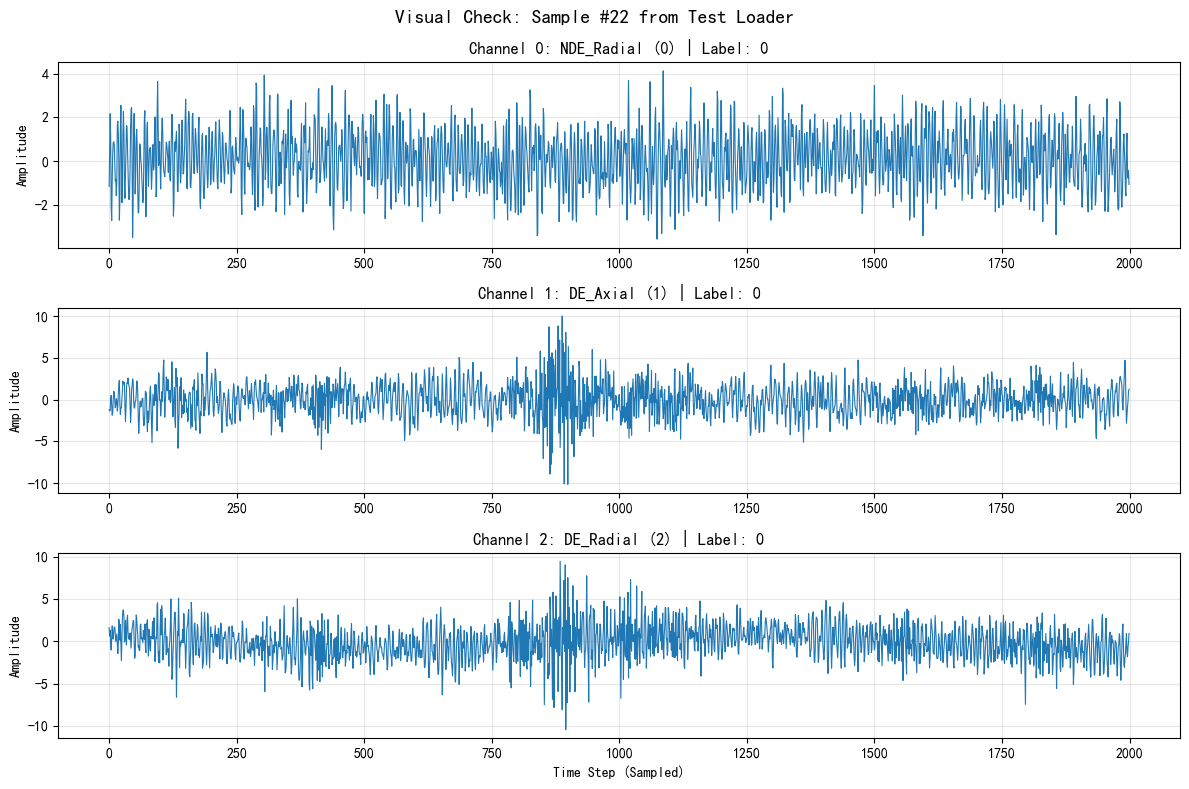


✅ 验证完成！数据流看起来非常健康，开始构建模型了。


In [238]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("🔍 开始验证测试集数据加载器 (Test Loader)...")

# 获取一个完整的 Batch 进行详细检查
try:
    batch = next(iter(test_loader))
except StopIteration:
    raise ValueError("❌ 错误：测试集 DataLoader 为空！请检查数据集划分。")

signal_batch = batch['signal']
feature_batch = batch['feature']
label_batch = batch['label']

# ==========================================
# 1. 基础形状与类型检查
# ==========================================
print("\n--- 1. 形状与类型检查 ---")
print(f"✅ Signal Batch Shape:  {signal_batch.shape}") 
# 期望: [Batch_Size, 3, Signal_Length]
print(f"✅ Feature Batch Shape: {feature_batch.shape}") 
# 期望: [Batch_Size, 3, Num_Features]
print(f"✅ Label Batch Shape:   {label_batch.shape}")   
# 期望: [Batch_Size]

assert signal_batch.dim() == 3, "❌ 信号维度错误！应为 3 维 (B, 3, L)"
assert feature_batch.dim() == 3, "❌ 特征维度错误！应为 3 维 (B, 3, F)"
assert label_batch.dim() == 1, "❌ 标签维度错误！应为 1 维 (B,)"

print(f"   - Signal Dtype: {signal_batch.dtype} (应为 torch.float32)")
print(f"   - Feature Dtype: {feature_batch.dtype} (应为 torch.float32)")
print(f"   - Label Dtype: {label_batch.dtype} (应为 torch.int64)")

# ==========================================
# 2. 数值有效性检查 (NaN/Inf)
# ==========================================
print("\n--- 2. 数值有效性检查 ---")
has_nan_sig = torch.isnan(signal_batch).any()
has_inf_sig = torch.isinf(signal_batch).any()
has_nan_feat = torch.isnan(feature_batch).any()

if has_nan_sig or has_inf_sig or has_nan_feat:
    print(f"⚠️ 警告：发现无效数值！")
    if has_nan_sig: print("   - 信号中存在 NaN")
    if has_inf_sig: print("   - 信号中存在 Inf")
    if has_nan_feat: print("   - 特征中存在 NaN")
else:
    print("✅ 数据干净：未发现 NaN 或 Inf。")

# ==========================================
# 3. 标签分布检查 (当前 Batch)
# ==========================================
print("\n--- 3. 当前 Batch 标签分布 ---")
unique, counts = torch.unique(label_batch, return_counts=True)
dist_dict = dict(zip(unique.tolist(), counts.tolist()))
print(f"   - 标签分布: {dist_dict}")
print(f"   - 正常样本 (0): {dist_dict.get(0, 0)}")
print(f"   - 故障样本 (1): {dist_dict.get(1, 0)}")

# ==========================================
# 4. 可视化验证 (随机抽取一个样本)
# ==========================================
print("\n--- 4. 可视化随机样本 ---")
idx = np.random.randint(0, len(label_batch))
sample_sig = signal_batch[idx].numpy()      # (3, L)
sample_feat = feature_batch[idx].numpy()    # (3, F)
sample_lbl = label_batch[idx].item()

print(f"   - 随机抽取样本索引: {idx}")
print(f"   - 该样本标签: {'故障 (1)' if sample_lbl == 1 else '正常 (0)'}")
print(f"   - 信号通道形状: {sample_sig.shape}")
print(f"   - 特征通道形状: {sample_feat.shape}")

# 绘制信号波形 (3 个通道)
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
channel_names = ['NDE_Radial (0)', 'DE_Axial (1)', 'DE_Radial (2)']

# 为了绘图清晰，只画前 2000 个点 (如果信号很长)
plot_len = min(2000, sample_sig.shape[1])

for i in range(3):
    axes[i].plot(sample_sig[i, :plot_len], linewidth=0.8)
    axes[i].set_title(f'Channel {i}: {channel_names[i]} | Label: {sample_lbl}')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step (Sampled)')
plt.suptitle(f'Visual Check: Sample #{idx} from Test Loader', fontsize=14)
plt.tight_layout()
plt.show()
print("\n✅ 验证完成！数据流看起来非常健康，开始构建模型了。")